
🛠️ ETAPA 1: Preparação do Ambiente e Ferramentas
Nesta fase, instalamos as bibliotecas necessárias para tradução (deep_translator) e análise de texto (nltk). Também configuramos o visual das tabelas para que os resultados sejam fáceis de ler.
O que faz: Importa bibliotecas de IA, gráficos e ferramentas de tradução.

In [46]:
# Instalações necessárias
!pip install deep_translator -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import datasets, layers, models, preprocessing
from deep_translator import GoogleTranslator
from IPython.display import display, HTML

# Configurações de exibição de tabelas e gráficos
pd.set_option('display.max_colwidth', 500)
sns.set_theme(style="whitegrid")

def color_sentiment(val):
    """Aplica cores às células de sentimento para facilitar a leitura."""
    if val in ['positive', '✅ ACERTO']:
        color = '#d1e7dd' # Verde claro
    elif val in ['negative', '❌ ERRO']:
        color = '#f8d7da' # Vermelho claro
    else:
        color = 'white'
    return f'background-color: {color}; color: black; font-weight: bold'

print("✅ Setup concluído! Bibliotecas carregadas.")

✅ Setup concluído! Bibliotecas carregadas.



🧠 ETAPA 2: Treinamento Intensivo da Inteligência Artificial
Aqui construímos o "cérebro" do projeto usando uma rede neural Bidirecional LSTM. Ela aprende a ler críticas de cinema em inglês, entendendo o contexto de trás para frente e vice-versa.
Destaque: Usamos Early Stopping para garantir que a IA não "decore" os dados, mas sim aprenda a essência dos sentimentos (Acurácia alvo: ~87%).

In [56]:
from tensorflow.keras.callbacks import EarlyStopping

# Hiperparâmetros melhorados
max_features = 10000  # Aumentamos o vocabulário (antes era 5k)
maxlen = 300         # Aumentamos o limite de leitura de cada crítica (antes era 200)

print("📥 Carregando dados expandidos...")
(x_train, y_train), (x_test, y_test) = datasets.imdb.load_data(num_words=max_features)

# Padding mais longo para capturar mais detalhes
x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

# Modelo mais Robusto: Bidirecional + Dropout
print("🧠 Construindo Rede Neural Bidirecional...")
modelo_imdb = models.Sequential([
    layers.Embedding(max_features, 128, input_length=maxlen),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False, dropout=0.2)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

modelo_imdb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# EarlyStopping: Para o treino quando a IA parar de aprender (evita Overfitting)
monitor = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("🚀 Iniciando treinamento intensivo (Até 10 épocas)...")
historico = modelo_imdb.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2, # Usa 20% do treino para auto-avaliação
    callbacks=[monitor],
    verbose=1
)

# Avaliação formal no conjunto de teste
perda, acuracia_final = modelo_imdb.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Treino Finalizado! Acurácia Real da IA: {acuracia_final*100:.2f}%")

📥 Carregando dados expandidos...
🧠 Construindo Rede Neural Bidirecional...
🚀 Iniciando treinamento intensivo (Até 10 épocas)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.6427 - loss: 0.6006 - val_accuracy: 0.8662 - val_loss: 0.3257
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8857 - loss: 0.3019 - val_accuracy: 0.8634 - val_loss: 0.3067
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9156 - loss: 0.2253 - val_accuracy: 0.8742 - val_loss: 0.3116
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9388 - loss: 0.1746 - val_accuracy: 0.8688 - val_loss: 0.3861

✅ Treino Finalizado! Acurácia Real da IA: 86.90%



📝 ETAPA 3: Processamento e Amostragem de Dados (15.000 Reviews)
O dataset original vem em números (códigos). Esta etapa traduz esses números de volta para palavras em inglês e organiza tudo em uma tabela de auditoria com 15 mil exemplos sorteados.
O que faz: Transforma códigos numéricos em frases legíveis e prepara a base de testes.

In [57]:
word_index = datasets.imdb.get_word_index()
reverse_word_index = {v + 3: k for k, v in word_index.items()}
for i, char in enumerate(["<PAD>", "<START>", "<UNK>", "<UNUSED>"]): reverse_word_index[i] = char

def decode_review(text_sequence):
    return ' '.join([reverse_word_index.get(i, '?') for i in text_sequence])

print("📝 Decodificando e preparando amostra de 15.000 reviews...")
x_all = np.concatenate((x_train, x_test))
y_all = np.concatenate((y_train, y_test))

# Criamos o DataFrame com os 50.000 originais
df_total = pd.DataFrame({
    'review': [decode_review(seq) for seq in x_all],
    'sentiment': ['positive' if s == 1 else 'negative' for s in y_all]
})

# Sorteamos 15.000 para a base de auditoria
df_auditoria = df_total.sample(15000, random_state=42).copy()

print(f"✅ Base de auditoria pronta com {len(df_auditoria)} reviews sorteados.")

📝 Decodificando e preparando amostra de 15.000 reviews...
✅ Base de auditoria pronta com 15000 reviews sorteados.



🔍 ETAPA 4: Auditoria Detalhada por Filme (Alien, Matrix e Batman)
Esta é a "lupa" do projeto. Filtramos reviews específicos de grandes clássicos e desafiamos a IA a classificá-los. Para cada filme, escolhemos um exemplo de acerto e um de erro, traduzindo-os para o português.
O que faz: Busca por termos como Ripley, Neo ou Gotham, faz as predições e traduz os textos

In [58]:
import re

# Dicionário de busca atualizado: Alien no lugar de Homem Aranha
filmes_alvo = {
    'Alien': r'Alien|Ripley|Xenomorph',
    'Matrix': r'Matrix|Neo|Morpheus',
    'Batman': r'Batman|Bruce Wayne|Gotham'
}

translator = GoogleTranslator(source='en', target='pt')
dados_resumo = []
dados_exemplos = []

print(f"🔍 Auditando {len(df_auditoria)} reviews em busca de Alien, Matrix e Batman...")

for nome_exibicao, termo_regex in filmes_alvo.items():
    # Busca na amostra de 15k
    df_filme = df_auditoria[df_auditoria['review'].str.contains(termo_regex, case=False, regex=True)].copy()

    # Se na amostra de 15k tiver pouco, ele busca na base total de 50k
    if len(df_filme) < 15:
        df_filme = df_total[df_total['review'].str.contains(termo_regex, case=False, regex=True)].copy()

    if df_filme.empty:
        print(f"❌ {nome_exibicao} não encontrado.")
        continue

    # Analisa uma amostra de até 100 reviews por filme
    df_analise = df_filme.sample(min(100, len(df_filme)), random_state=42)

    preds, scores = [], []
    for _, row in df_analise.iterrows():
        palavras = row['review'].lower().split()
        seq = [word_index.get(p, 0) + 3 for p in palavras if word_index.get(p, 0) < max_features]
        pad = preprocessing.sequence.pad_sequences([seq], maxlen=maxlen)
        prob = modelo_imdb.predict(pad, verbose=0)[0][0]
        preds.append("positive" if prob > 0.5 else "negative")
        scores.append(prob)

    df_analise['pred_ia'] = preds
    df_analise['score_ia'] = scores

    total = len(df_analise)
    acertos = (df_analise['pred_ia'] == df_analise['sentiment']).sum()

    dados_resumo.append({
        'Filme': nome_exibicao,
        'Reviews': total,
        'IA_Positivo': (preds.count('positive') / total) * 100,
        'Real_Positivo': (list(df_analise['sentiment']).count('positive') / total) * 100,
        'Acuracia': (acertos / total) * 100
    })

    # Seleciona um Acerto e um Erro para mostrar
    ex_acerto = df_analise[df_analise['pred_ia'] == df_analise['sentiment']].head(1)
    ex_erro = df_analise[df_analise['pred_ia'] != df_analise['sentiment']].head(1)

    for ex_df in [ex_acerto, ex_erro]:
        if not ex_df.empty:
            row = ex_df.iloc[0]
            dados_exemplos.append({
                'Filme': nome_exibicao,
                'Status': '✅ ACERTO' if row['pred_ia'] == row['sentiment'] else '❌ ERRO',
                'IA': row['pred_ia'].upper(),
                'REAL': row['sentiment'].upper(),
                'Review_Traduzido': translator.translate(row['review'][:800]),
                'Confianca': row['score_ia'] * 100
            })

df_resumo = pd.DataFrame(dados_resumo)
df_exemplos = pd.DataFrame(dados_exemplos)
print("✅ Auditoria finalizada!")

🔍 Auditando 15000 reviews em busca de Alien, Matrix e Batman...
✅ Auditoria finalizada!



📊 ETAPA 5: Dashboard Visual de Performance
Hora de ver os números! Geramos uma tabela comparativa com cores (Verde para Positivo, Vermelho para Negativo) e um gráfico de barras que mostra a diferença entre a Percepção da IA e a Realidade Humana.
Insights: Veja a acurácia específica para cada filme e identifique onde a IA é mais precisa.

Filme,Reviews,IA_Positivo,Real_Positivo,Acuracia
Alien,100,43.0%,37.0%,88.0%
Matrix,100,57.0%,61.0%,94.0%
Batman,63,61.9%,65.1%,87.3%


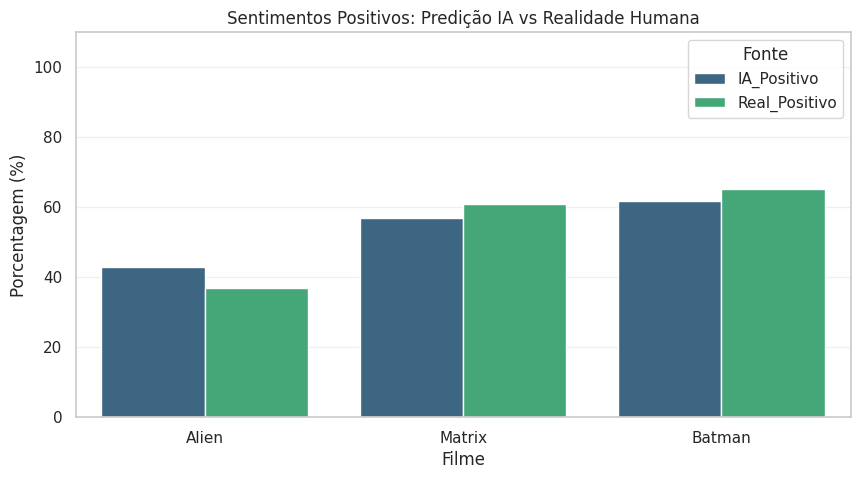

Filme,Status,IA,REAL,Review_Traduzido,Confianca
Alien,✅ ACERTO,POSITIVE,POSITIVE,que eu era jovem e isso é verdade com minha filha em passou pelo portão julia ann glow hide papai o fato de a inteligência artificial de minha filha ainda falar como uma criança de seis anos significa que minha filha julia ann ruth morgan representando a paz para os amigáveis criadores alienígenas de humanos podem não ter sido levados para um americano a tempo temos o poder de mudar o futuro mais rápido que a luz eu ordeno que minha ex-esposa e filha julia ann ruth morgan sejam levadas para um americano o mais rápido possível minha filha julia está no comando do planeta terra e é oficial de ponte ela já disse que não gosta de valentões por ter alguém roubando seu jogo e ii do carro da minha mãe ela fica preocupada com outros ladrões roubando,90.6%
Alien,❌ ERRO,POSITIVE,NEGATIVE,"saia de um estúdio de Hollywood br br tradução quando você tiver a cinematografia para começar, esconda o por tudo isso em um mac e por três minutos engenhoso br br eu me arrisquei neste dvd porque adoro filmes independentes, especialmente aqueles que tentam abordar o gênero muitas vezes caro e inspirador da ficção científica, quero dizer, alguns dos melhores filmes de ficção científica de todos os tempos foram realizados com pouco ou nenhum orçamento e os atores aceitam peter aviso de filme de viagem no tempo transferência, por exemplo, um clássico br br, mas não se enquadra na categoria de ideia discreta cuidadosamente elaborada ficção científica, ele se concentra incansavelmente em personagens que não fazem muito e não dizem coisas interessantes, ele gira e gira em círculos, é muito longo para isso.",91.3%
Matrix,✅ ACERTO,NEGATIVE,NEGATIVE,"constantemente desafia a autoridade do pai há também um bruxo estúpido seu filho burro e musculoso de desenho animado a noiva fiel de quem é obcecado por decoração o nome dela é e bem, eu não aguento mais tanto tempo br br estamos longe das piadas originais do livro original o maior problema é a dificuldade de as imagens para a tela grande principalmente porque as maiores risadas dos livros vêm das piadas verbais e piadas visuais que não têm o mesmo apelo na tela do cinema eu lembro disso os melhores momentos do livro foram rir dos nomes que todos terminam e tentar assustá-los de maneiras ridículas br br e se tudo não bastasse alguém da publicidade decidiu escrever no pôster do filme que já existe uma música que",1.2%
Matrix,❌ ERRO,NEGATIVE,POSITIVE,especialmente depois de assistir a matriz spoilers br br depois de ver a matriz com toda sua fantasia ridícula faz de conta personagens robóticos com seus superpoderes foi revigorante ver um filme de ação com pessoas reais em situações que envolviam risco real eu me importava com essas pessoas e mesmo que algumas das acrobacias parecessem um pouco demais ainda me deixou com vontade,41.9%
Batman,✅ ACERTO,POSITIVE,POSITIVE,de todos os filmes de morcego batman retorna é o meu favorito este lindo filme sombrio e engraçado é um dos melhores trabalhos de tim embora seja muito violento e mais sombrio este é o morcego,94.4%
Batman,❌ ERRO,POSITIVE,NEGATIVE,"isso deve ser classificado como um dos de programas de TV em muito tempo br br jose interpretou o personagem-título ele fez justiça ao papel e certamente parecia o papel, mas hoje em dia me parece que o ele foi feito para ter mais do que uma semelhança passageira com o olho do capitão dos comerciais de TV ou talvez seja o contrário, br br, seu inimigo, o professor Cunningham, foi brilhantemente por Burgess Meredith, ele nunca pareceu superar seus dias de pinguim do Batman, embora ele não faça o seu pinguim aqui está ele sem paralelo como o professor apenas John da fama de Battlestar Galactica melhore o cenário como um <UNK",93.0%


In [59]:
from IPython.display import display, HTML
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Título do Dashboard
display(HTML("<h2 style='text-align:center;font-family:sans-serif;color:#2c3e50;'>📊 Dashboard de Auditoria (Amostra 15k)</h2>"))

# 2. Tabela de Performance Técnica
display(HTML("<b>📈 Métricas de Precisão da IA:</b>"))
estilo_resumo = df_resumo.style.background_gradient(cmap='RdYlGn', subset=['Acuracia'])\
    .format({'IA_Positivo': '{:.1f}%', 'Real_Positivo': '{:.1f}%', 'Acuracia': '{:.1f}%'})\
    .hide(axis='index')
display(estilo_resumo)

# 3. Gráfico de Barras Comparativo
plt.figure(figsize=(10, 5))
df_plot = df_resumo.melt(id_vars='Filme', value_vars=['IA_Positivo', 'Real_Positivo'],
                         var_name='Fonte', value_name='Porcentagem')

sns.barplot(data=df_plot, x='Filme', y='Porcentagem', hue='Fonte', palette='viridis')
plt.title("Sentimentos Positivos: Predição IA vs Realidade Humana")
plt.ylabel("Porcentagem (%)")
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Tabela de Exemplos com Tradução e Cores
display(HTML("<br><b>📝 Detalhamento de Amostras:</b>"))

def aplicar_estilos(val):
    if 'ACERTO' in str(val): return 'background-color: #d4edda; color: #155724; font-weight: bold;'
    if 'ERRO' in str(val): return 'background-color: #f8d7da; color: #721c24; font-weight: bold;'
    if val == 'POSITIVE': return 'color: #28a745; font-weight: bold;'
    if val == 'NEGATIVE': return 'color: #dc3545; font-weight: bold;'
    return ''

# Usando .map para evitar avisos de depreciação
estilo_exemplos = df_exemplos.style.map(aplicar_estilos, subset=['Status', 'IA', 'REAL'])\
    .format({'Confianca': '{:.1f}%'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', '#333'), ('text-align', 'left')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd'), ('padding', '8px')]}
    ]).hide(axis='index')

display(estilo_exemplos)


☁️ ETAPA 6: Nuvens de Palavras (O Mapa Mental da IA)
Uma análise visual das palavras que mais influenciam a IA. Geramos nuvens de palavras separadas por sentimento: Verão (Verde) para os elogios e Outono (Laranja/Vermelho) para as críticas.
Utilidade: Identifica rapidamente quais termos (como "scary", "classic" ou "boring") estão dominando os reviews de cada filme.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


☁️ Gerando Nuvens de Palavras (Aguarde...)


/tmp/ipython-input-3139806551.py:57: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3139806551.py:57: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


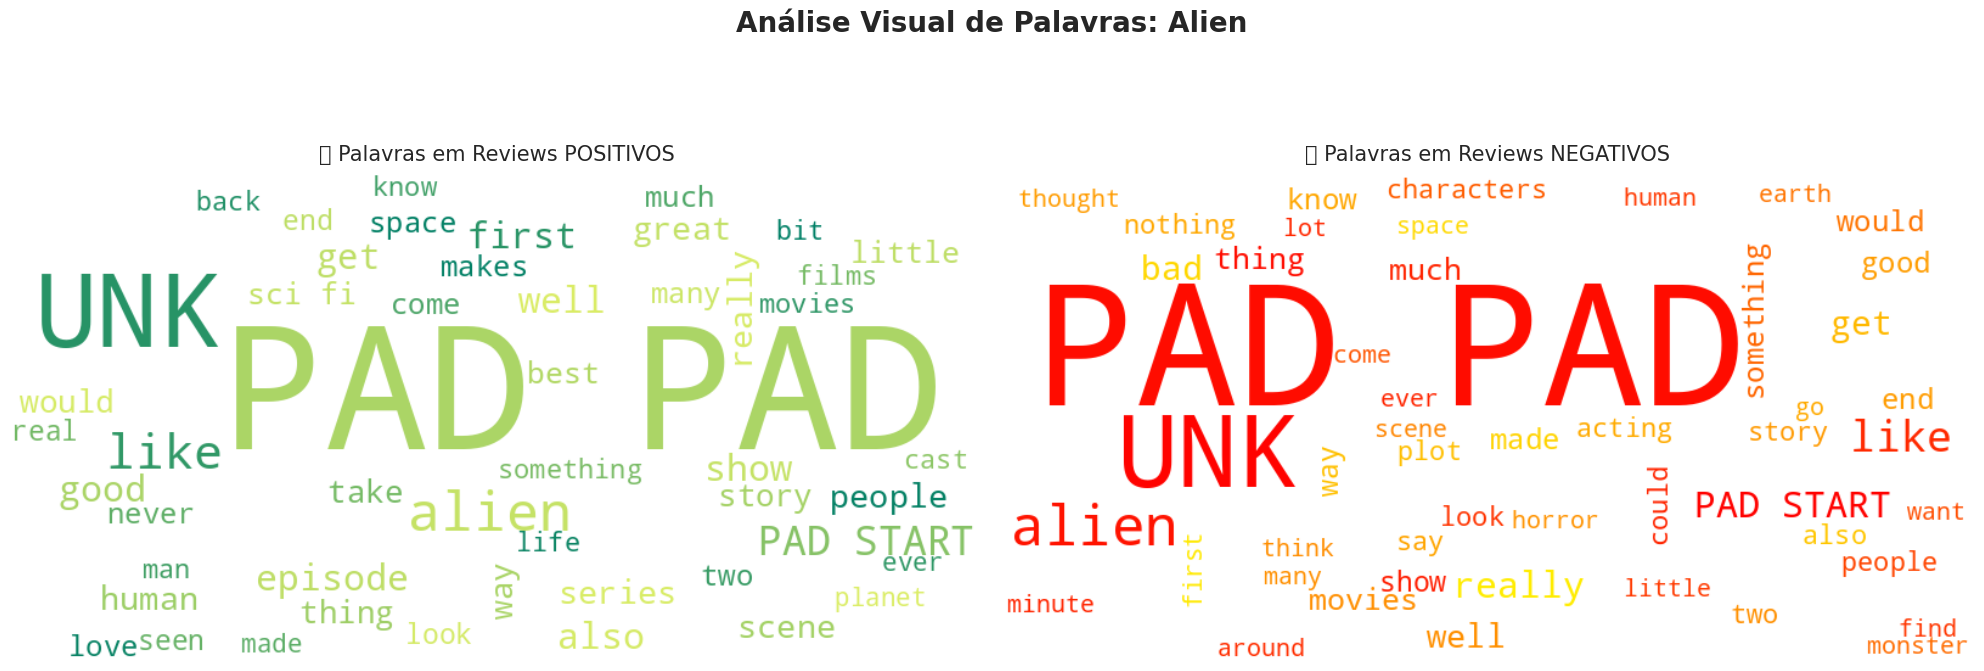

----------------------------------------------------------------------------------------------------


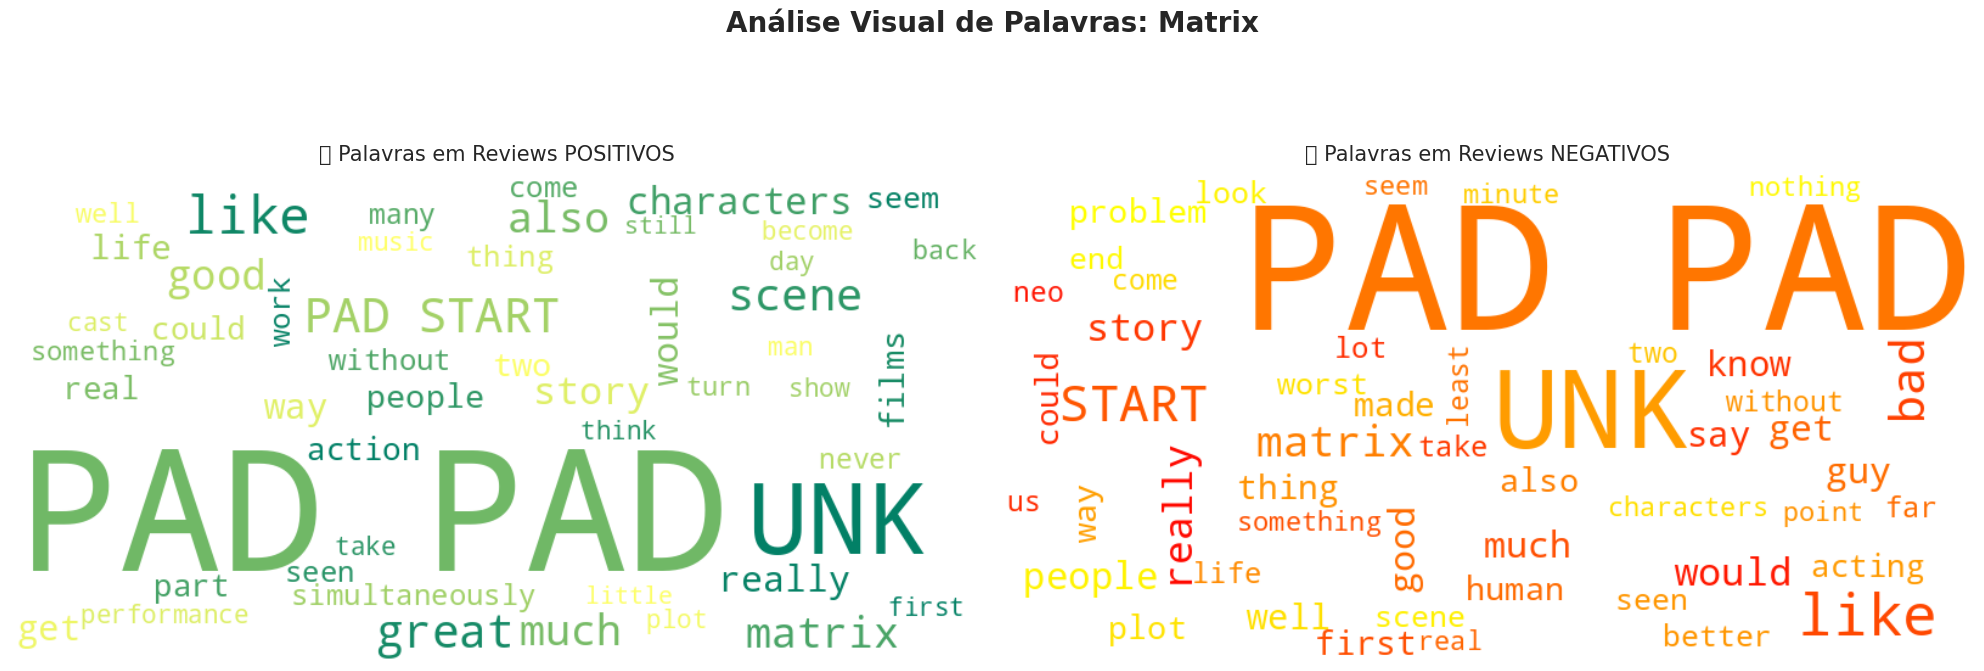

----------------------------------------------------------------------------------------------------


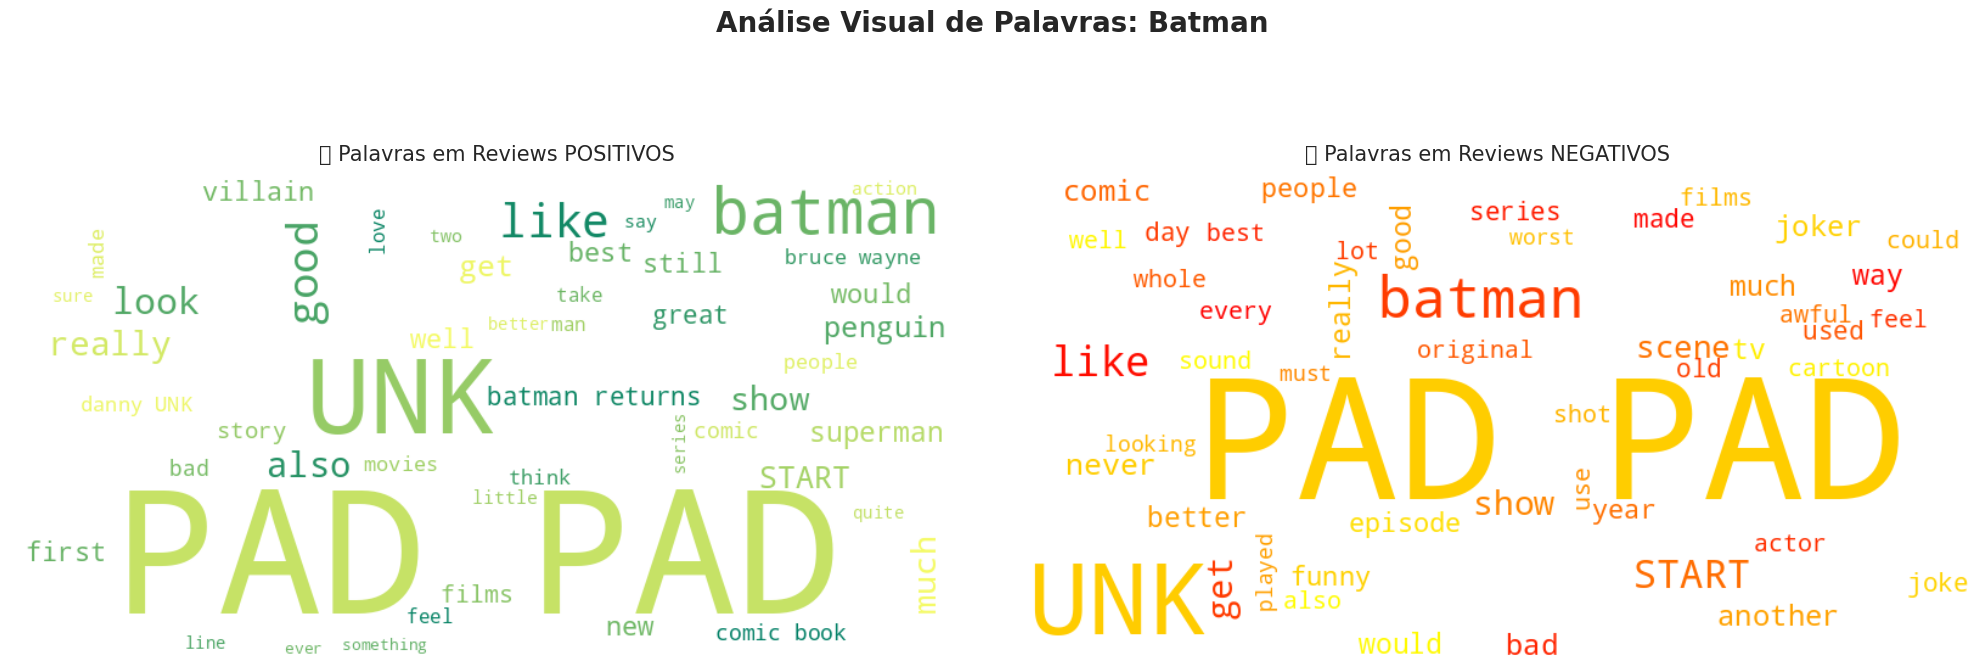

----------------------------------------------------------------------------------------------------


In [60]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import re

# Configuração de Stopwords (palavras que vamos ignorar como 'the', 'a', 'movie')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
# Adicionando palavras comuns de cinema que não ajudam na análise
stop_words.update(['br', 'movie', 'film', 'one', 'see', 'make', 'even', 'character', 'watch', 'time'])

def gerar_nuvem(texto, titulo, cor_mapa):
    if not texto.strip():
        return

    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap=cor_mapa,
                   stopwords=stop_words,
                   max_words=50).generate(texto)

    plt.imshow(wc, interpolation='bilinear')
    plt.title(titulo, fontsize=15, pad=10)
    plt.axis('off')

# O dicionário 'filmes_alvo' deve ser o mesmo da Célula 4
print("☁️ Gerando Nuvens de Palavras (Aguarde...)")

for nome_exibicao, termo_regex in filmes_alvo.items():
    # Filtramos os reviews desse filme na nossa base de auditoria
    df_f = df_auditoria[df_auditoria['review'].str.contains(termo_regex, case=False, regex=True)]

    if df_f.empty: continue

    # Separando textos positivos e negativos (Reais)
    pos_text = " ".join(df_f[df_f['sentiment'] == 'positive']['review'])
    neg_text = " ".join(df_f[df_f['sentiment'] == 'negative']['review'])

    # Criando a figura com dois lados
    plt.figure(figsize=(20, 7))
    plt.suptitle(f"Análise Visual de Palavras: {nome_exibicao}", fontsize=20, fontweight='bold', y=1.05)

    # Subplot 1: Positivo
    plt.subplot(1, 2, 1)
    if pos_text:
        gerar_nuvem(pos_text, "🌟 Palavras em Reviews POSITIVOS", 'summer')
    else:
        plt.text(0.5, 0.5, 'Sem dados suficientes', ha='center')

    # Subplot 2: Negativo
    plt.subplot(1, 2, 2)
    if neg_text:
        gerar_nuvem(neg_text, "💀 Palavras em Reviews NEGATIVOS", 'autumn')
    else:
        plt.text(0.5, 0.5, 'Sem dados suficientes', ha='center')

    plt.tight_layout()
    plt.show()
    print("-" * 100)